In [1]:
import pandas as pd
import numpy as np

# 1. Load Dataset
df = pd.read_csv('neso_data.csv')

In [2]:
# -------------------------------
# 2. Feature Engineering
# -------------------------------

# Combine renewables
df["renewables"] = (
    df["EMBEDDED_WIND_GENERATION"] +
    df["EMBEDDED_SOLAR_GENERATION"]
)

# Combine ALL interconnector flows
interconnector_cols = [
    "IFA_FLOW", "IFA2_FLOW", "BRITNED_FLOW",
    "MOYLE_FLOW", "EAST_WEST_FLOW", "NEMO_FLOW",
    "NSL_FLOW", "ELECLINK_FLOW", "VIKING_FLOW", "GREENLINK_FLOW"
]

df["interconnector"] = df[interconnector_cols].sum(axis=1)

In [3]:

# -------------------------------
# 3. Normalisation


def min_max_normalise(series):
    return (series - series.min()) / (series.max() - series.min())

df["demand_norm"] = min_max_normalise(df["ND"])
df["renewables_norm"] = min_max_normalise(df["renewables"])
df["interconnector_norm"] = min_max_normalise(df["interconnector"])

In [4]:
# 4. Parameters


BASE_PRICE = 50
ALPHA = 40
BETA = 30
GAMMA = 20
DELTA = 60

In [5]:
# 5. Price Model

def calculate_price(row):
    demand = row["demand_norm"]
    renewables = row["renewables_norm"]
    interconnector = row["interconnector_norm"]

    price = (
        BASE_PRICE
        + ALPHA * demand
        - BETA * renewables
        - GAMMA * interconnector
    )

    # Stress (price spikes)
    stress = demand - renewables
    if stress > 0:
        price += DELTA * (stress ** 2)

    return max(price, 0)

df["simulated_price"] = df.apply(calculate_price, axis=1)

In [6]:

# 6. Add Time Feature (from settlement period)
# -------------------------------

# Each settlement period = 30 mins → convert to hour
df["hour"] = (df["SETTLEMENT_PERIOD"] - 1) / 2

def add_peak_premium(row):
    if 7 <= row["hour"] <= 10 or 16 <= row["hour"] <= 20:
        return row["simulated_price"] + 10
    return row["simulated_price"]

df["simulated_price"] = df.apply(add_peak_premium, axis=1)

In [7]:
df.to_csv("simulated_prices.csv", index=False)

print(df[["SETTLEMENT_DATE", "SETTLEMENT_PERIOD", "simulated_price"]].head())

  SETTLEMENT_DATE  SETTLEMENT_PERIOD  simulated_price
0      01/01/2026                  1        43.886251
1      01/01/2026                  2        44.735271
2      01/01/2026                  3        44.951695
3      01/01/2026                  4        44.185490
4      01/01/2026                  5        42.899668


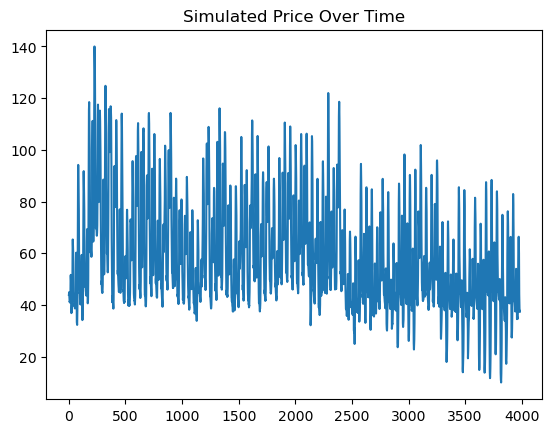

In [8]:
import matplotlib.pyplot as plt

plt.plot(df["simulated_price"])
plt.title("Simulated Price Over Time")
plt.show()

In [9]:
df[["renewables", "simulated_price"]].corr()

,renewables,simulated_price
renewables,1.000000,-0.455621
simulated_price,-0.455621,1.000000


In [10]:
print(df["simulated_price"].max())

140.00461360335015


In [11]:
df[["ND", "simulated_price"]].corr()

,ND,simulated_price
ND,1.000000,0.872385
simulated_price,0.872385,1.000000
